In [ ]:
!pip -q install pyspark openpyxl

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, when, round as sp_round
from pyspark.sql.functions import unix_timestamp, date_format, hour, dayofweek, month, year

spark = SparkSession.builder.appName("TransLogix-Shipments").getOrCreate()
spark


# **reading Excel using Pandas, then convert to Spark**

In [ ]:
import pandas as pd

pdf = pd.read_excel("shipments.xlsx")   # reads shipments.xlsx
print(pdf.shape)
pdf.head()


(100000, 29)


,shipment_id,origin_hub,destination_hub,route_id,scheduled_departure,distance_km,product_weight_kg,fragile,transport_mode,vehicle_id,...,destination_hub_name,origin_country,destination_country,origin_region,destination_region,origin_lat,origin_lon,destination_lat,destination_lon,route_name
0,SHP463810,DXB01,BAH12,DXB01-BAH12,2024-01-01 16:15:00,482.901405,2884.5,No,SEA,VSL-8013,...,Bahrain Regional Hub,United Arab Emirates,Bahrain,GCC Central Region,GCC Northern Region,25.2048,55.2708,26.2285,50.586,Dubai Central Hub -> Bahrain Regional Hub
1,SHP480570,DXB01,BAH12,DXB01-BAH12,2024-01-01 18:15:00,482.901405,1493.2,No,SEA,VSL-8022,...,Bahrain Regional Hub,United Arab Emirates,Bahrain,GCC Central Region,GCC Northern Region,25.2048,55.2708,26.2285,50.586,Dubai Central Hub -> Bahrain Regional Hub
2,SHP484364,DXB01,BAH12,DXB01-BAH12,2024-01-02 08:00:00,482.901405,1726.0,Yes,SEA,VSL-8003,...,Bahrain Regional Hub,United Arab Emirates,Bahrain,GCC Central Region,GCC Northern Region,25.2048,55.2708,26.2285,50.586,Dubai Central Hub -> Bahrain Regional Hub
3,SHP426868,DXB01,BAH12,DXB01-BAH12,2024-01-02 12:45:00,482.901405,1267.9,No,SEA,VSL-8011,...,Bahrain Regional Hub,United Arab Emirates,Bahrain,GCC Central Region,GCC Northern Region,25.2048,55.2708,26.2285,50.586,Dubai Central Hub -> Bahrain Regional Hub
4,SHP412023,DXB01,BAH12,DXB01-BAH12,2024-01-03 07:15:00,482.901405,2274.7,No,SEA,VSL-8011,...,Bahrain Regional Hub,United Arab Emirates,Bahrain,GCC Central Region,GCC Northern Region,25.2048,55.2708,26.2285,50.586,Dubai Central Hub -> Bahrain Regional Hub


In [ ]:
df = spark.createDataFrame(pdf)
df.printSchema()
df.show(5)


root
 |-- shipment_id: string (nullable = true)
 |-- origin_hub: string (nullable = true)
 |-- destination_hub: string (nullable = true)
 |-- route_id: string (nullable = true)
 |-- scheduled_departure: timestamp (nullable = true)
 |-- distance_km: double (nullable = true)
 |-- product_weight_kg: double (nullable = true)
 |-- fragile: string (nullable = true)
 |-- transport_mode: string (nullable = true)
 |-- vehicle_id: string (nullable = true)
 |-- vehicle_reliability: double (nullable = true)
 |-- planned_transit_hours: double (nullable = true)
 |-- scheduled_arrival: timestamp (nullable = true)
 |-- origin_congestion_idx: double (nullable = true)
 |-- dest_congestion_idx: double (nullable = true)
 |-- actual_departure: timestamp (nullable = true)
 |-- actual_arrival: timestamp (nullable = true)
 |-- delay_minutes: double (nullable = true)
 |-- origin_hub_name: string (nullable = true)
 |-- destination_hub_name: string (nullable = true)
 |-- origin_country: string (nullable = true)


In [ ]:
df.select("shipment_id","distance_km").show()

+-----------+-----------+
|shipment_id|distance_km|
+-----------+-----------+
|  SHP463810|482.9014049|
|  SHP480570|482.9014049|
|  SHP484364|482.9014049|
|  SHP426868|482.9014049|
|  SHP412023|482.9014049|
|  SHP453619|482.9014049|
|  SHP498664|482.9014049|
|  SHP449048|482.9014049|
|  SHP413559|482.9014049|
|  SHP411031|482.9014049|
|  SHP411747|482.9014049|
|  SHP447557|482.9014049|
|  SHP441509|482.9014049|
|  SHP484945|482.9014049|
|  SHP493467|482.9014049|
|  SHP435402|482.9014049|
|  SHP442136|482.9014049|
|  SHP465763|482.9014049|
|  SHP463541|482.9014049|
|  SHP431531|482.9014049|
+-----------+-----------+
only showing top 20 rows


# **Data cleaning + type fixing**

In [ ]:
time_cols = ["scheduled_departure", "scheduled_arrival", "actual_departure", "actual_arrival"]
df2 = df
for c in time_cols:
    df2 = df2.withColumn(c, to_timestamp(col(c)))
# Ensure delay_minutes is numeric (it already is, but safe)
df2 = df2.withColumn("delay_minutes", col("delay_minutes").cast("double"))
# Remove duplicates based on shipment_id (safe cleaning)
df2 = df2.dropDuplicates(["shipment_id"])
# Filter out rows with missing key fields (cleaning filter)
df2 = df2.filter(
    col("shipment_id").isNotNull() &
    col("scheduled_departure").isNotNull() &
    col("scheduled_arrival").isNotNull() &
    col("actual_departure").isNotNull() &
    col("actual_arrival").isNotNull())
df2.select("shipment_id","route_id","origin_hub","destination_hub","delay_minutes").show(5)
print("Rows after cleaning:", df2.count())
# Investigate shipments with high delays > 60 minutes
high_delay_df = df2.filter(col("delay_minutes") > 60)
print("Shipments delayed more than 60 minutes:", high_delay_df.count())
high_delay_df.select(
    "shipment_id",
    "origin_hub_name",
    "destination_hub_name",
    "route_name",
    "delay_minutes",
    "origin_congestion_idx",
    "dest_congestion_idx").orderBy(col("delay_minutes").desc()).show(10, truncate=False)


+-----------+-----------+----------+---------------+-------------+
|shipment_id|   route_id|origin_hub|destination_hub|delay_minutes|
+-----------+-----------+----------+---------------+-------------+
|  SHP400001|DXB01-RUH05|     DXB01|          RUH05|         54.0|
|  SHP400005|DXB01-BAH12|     DXB01|          BAH12|         32.0|
|  SHP400006|DXB01-BAH12|     DXB01|          BAH12|         31.0|
|  SHP400011|JED20-DXB01|     JED20|          DXB01|         45.0|
|  SHP400013|DXB01-RUH05|     DXB01|          RUH05|         18.0|
+-----------+-----------+----------+---------------+-------------+
only showing top 5 rows
Rows after cleaning: 99607
Shipments delayed more than 60 minutes: 12460
+-----------+-----------------------+-----------------------+-----------------------------------------------+-------------+---------------------+-------------------+
|shipment_id|origin_hub_name        |destination_hub_name   |route_name                                     |delay_minutes|origin_cong

# **Create useful new columns**

In [ ]:
# Recalculate delay from times (validation)
df2 = df2.withColumn(
    "delay_minutes_calc",
    sp_round((unix_timestamp(col("actual_arrival")) - unix_timestamp(col("scheduled_arrival"))) / 60, 2)
)
# Status label
df2 = df2.withColumn(
    "delivery_status",
    when(col("delay_minutes") <= 0, "On-time").otherwise("Late")
)
# Time features
df2 = df2.withColumn("dep_year", year(col("scheduled_departure"))) \
         .withColumn("dep_month", month(col("scheduled_departure"))) \
         .withColumn("dep_dayofweek", dayofweek(col("scheduled_departure"))) \
         .withColumn("dep_hour", hour(col("scheduled_departure")))
# Simple peak-hour flag
df2 = df2.withColumn(
    "is_peak_hour",
    when((col("dep_hour") >= 7) & (col("dep_hour") <= 10), 1)
    .when((col("dep_hour") >= 16) & (col("dep_hour") <= 19), 1)
    .otherwise(0))
df2.select("shipment_id","delay_minutes","delay_minutes_calc","delivery_status","dep_hour","is_peak_hour").show(10)


+-----------+-------------+------------------+---------------+--------+------------+
|shipment_id|delay_minutes|delay_minutes_calc|delivery_status|dep_hour|is_peak_hour|
+-----------+-------------+------------------+---------------+--------+------------+
|  SHP498664|         19.0|              19.0|           Late|       3|           0|
|  SHP417648|         48.0|              48.0|           Late|      16|           1|
|  SHP465161|         49.0|              49.0|           Late|      21|           0|
|  SHP478364|         34.0|              34.0|           Late|       8|           1|
|  SHP436863|         51.0|              51.0|           Late|      15|           0|
|  SHP485438|         34.0|              34.0|           Late|      11|           0|
|  SHP439946|         69.0|              69.0|           Late|       7|           1|
|  SHP468225|         34.0|              34.0|           Late|       6|           0|
|  SHP452448|         44.0|              44.0|           Late|   

# **Delay by hub (origin + destination)**

In [ ]:
from pyspark.sql.functions import avg, count, max as sp_max

origin_hub_summary = df2.groupBy("origin_hub_name").agg(
    count("*").alias("shipments"),
    sp_round(avg("delay_minutes"), 2).alias("avg_delay_min"),
    sp_round(sp_max("delay_minutes"), 2).alias("max_delay_min"),
    sp_round(avg("origin_congestion_idx"), 2).alias("avg_origin_congestion")
).orderBy(col("avg_delay_min").desc())

dest_hub_summary = df2.groupBy("destination_hub_name").agg(
    count("*").alias("shipments"),
    sp_round(avg("delay_minutes"), 2).alias("avg_delay_min"),
    sp_round(sp_max("delay_minutes"), 2).alias("max_delay_min"),
    sp_round(avg("dest_congestion_idx"), 2).alias("avg_dest_congestion")
).orderBy(col("avg_delay_min").desc())

origin_hub_summary.show(10, truncate=False)
dest_hub_summary.show(10, truncate=False)


+-----------------------+---------+-------------+-------------+---------------------+
|origin_hub_name        |shipments|avg_delay_min|max_delay_min|avg_origin_congestion|
+-----------------------+---------+-------------+-------------+---------------------+
|Dubai Central Hub      |49967    |42.87        |217.0        |0.31                 |
|Jeddah Distribution Hub|24824    |41.49        |316.0        |0.3                  |
|Riyadh Logistics Hub   |24816    |24.84        |192.0        |0.28                 |
+-----------------------+---------+-------------+-------------+---------------------+

+-----------------------+---------+-------------+-------------+-------------------+
|destination_hub_name   |shipments|avg_delay_min|max_delay_min|avg_dest_congestion|
+-----------------------+---------+-------------+-------------+-------------------+
|Riyadh Logistics Hub   |24916    |43.38        |201.0        |0.27               |
|Bahrain Regional Hub   |25051    |42.36        |217.0       

# **Delay by route**

In [ ]:
route_summary = df2.groupBy("route_name").agg(
    count("*").alias("shipments"),
    sp_round(avg("delay_minutes"), 2).alias("avg_delay_min"),
    sp_round(sp_max("delay_minutes"), 2).alias("max_delay_min"),
    sp_round(avg("origin_congestion_idx"), 2).alias("avg_origin_congestion"),
    sp_round(avg("dest_congestion_idx"), 2).alias("avg_dest_congestion")
).orderBy(col("avg_delay_min").desc())

route_summary.show(10, truncate=False)


+-----------------------------------------------+---------+-------------+-------------+---------------------+-------------------+
|route_name                                     |shipments|avg_delay_min|max_delay_min|avg_origin_congestion|avg_dest_congestion|
+-----------------------------------------------+---------+-------------+-------------+---------------------+-------------------+
|Dubai Central Hub -> Riyadh Logistics Hub      |24916    |43.38        |201.0        |0.31                 |0.27               |
|Dubai Central Hub -> Bahrain Regional Hub      |25051    |42.36        |217.0        |0.31                 |0.26               |
|Jeddah Distribution Hub -> Dubai Central Hub   |24824    |41.49        |316.0        |0.3                  |0.27               |
|Riyadh Logistics Hub -> Jeddah Distribution Hub|24816    |24.84        |192.0        |0.28                 |0.27               |
+-----------------------------------------------+---------+-------------+-------------+---

# **Congestion vs delay**

In [ ]:
route_summary = df2.groupBy("route_name").agg(
    count("*").alias("shipments"),
    sp_round(avg("delay_minutes"), 2).alias("avg_delay_min"),
    sp_round(sp_max("delay_minutes"), 2).alias("max_delay_min"),
    sp_round(avg("origin_congestion_idx"), 2).alias("avg_origin_congestion"),
    sp_round(avg("dest_congestion_idx"), 2).alias("avg_dest_congestion")
).orderBy(col("avg_delay_min").desc())

route_summary.show(10, truncate=False)


+-----------------------------------------------+---------+-------------+-------------+---------------------+-------------------+
|route_name                                     |shipments|avg_delay_min|max_delay_min|avg_origin_congestion|avg_dest_congestion|
+-----------------------------------------------+---------+-------------+-------------+---------------------+-------------------+
|Dubai Central Hub -> Riyadh Logistics Hub      |24916    |43.38        |201.0        |0.31                 |0.27               |
|Dubai Central Hub -> Bahrain Regional Hub      |25051    |42.36        |217.0        |0.31                 |0.26               |
|Jeddah Distribution Hub -> Dubai Central Hub   |24824    |41.49        |316.0        |0.3                  |0.27               |
|Riyadh Logistics Hub -> Jeddah Distribution Hub|24816    |24.84        |192.0        |0.28                 |0.27               |
+-----------------------------------------------+---------+-------------+-------------+---

# **Python visualizationsa**

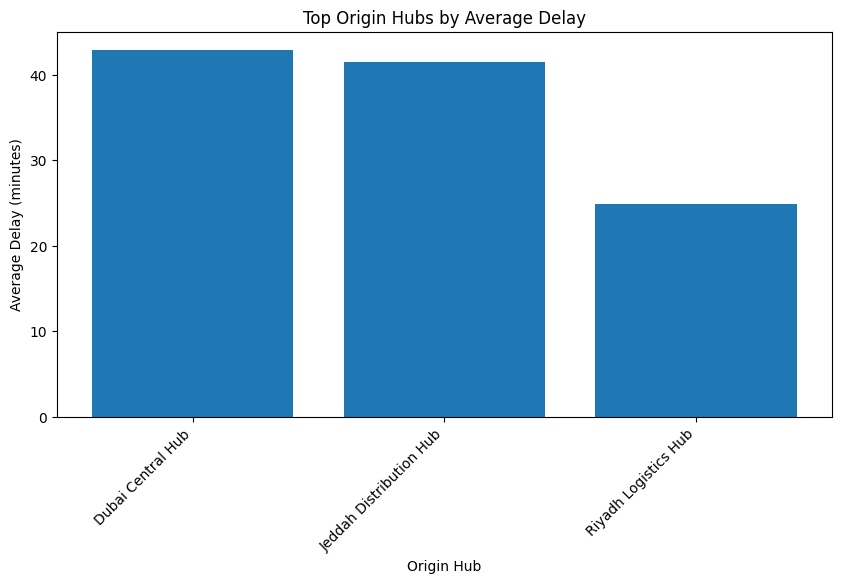

In [ ]:
import matplotlib.pyplot as plt

# Top 10 origin hubs by avg delay
hub_pd = origin_hub_summary.limit(10).toPandas()

plt.figure(figsize=(10,5))
plt.bar(hub_pd["origin_hub_name"], hub_pd["avg_delay_min"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Origin Hub")
plt.ylabel("Average Delay (minutes)")
plt.title("Top Origin Hubs by Average Delay")
plt.show()


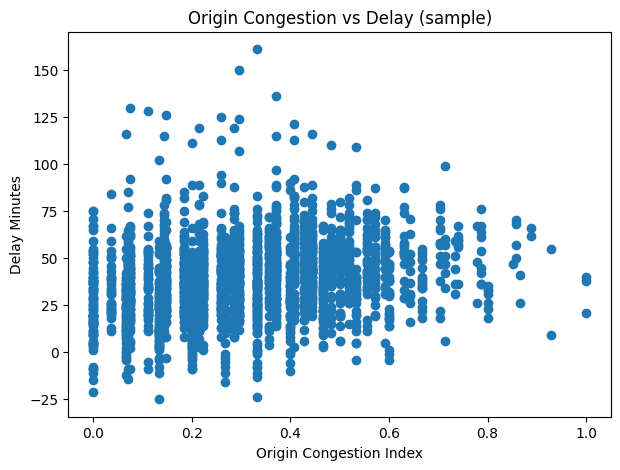

In [ ]:
sample_pd = df2.select("delay_minutes","origin_congestion_idx").sample(False, 0.02, seed=42).toPandas()

plt.figure(figsize=(7,5))
plt.scatter(sample_pd["origin_congestion_idx"], sample_pd["delay_minutes"])
plt.xlabel("Origin Congestion Index")
plt.ylabel("Delay Minutes")
plt.title("Origin Congestion vs Delay (sample)")
plt.show()


# **Heatmap: Average delay by hour**

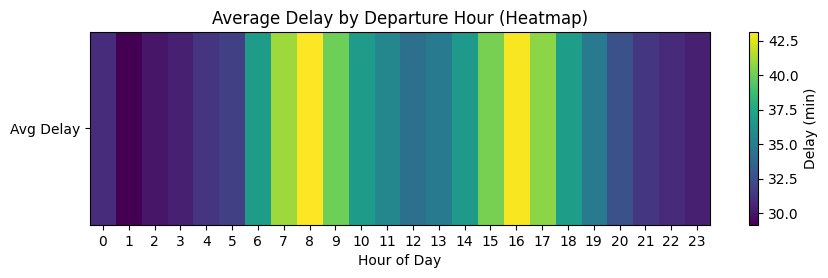

In [ ]:
hour_delay = df2.groupBy("dep_hour").agg(
    sp_round(avg("delay_minutes"), 2).alias("avg_delay_min")
).orderBy("dep_hour")

h_pd = hour_delay.toPandas()

plt.figure(figsize=(10,2.5))
plt.imshow([h_pd["avg_delay_min"].values], aspect="auto")
plt.yticks([0], ["Avg Delay"])
plt.xticks(range(24), range(24))
plt.xlabel("Hour of Day")
plt.title("Average Delay by Departure Hour (Heatmap)")
plt.colorbar(label="Delay (min)")
plt.show()


# **Bar chart: Average delay by day of week**

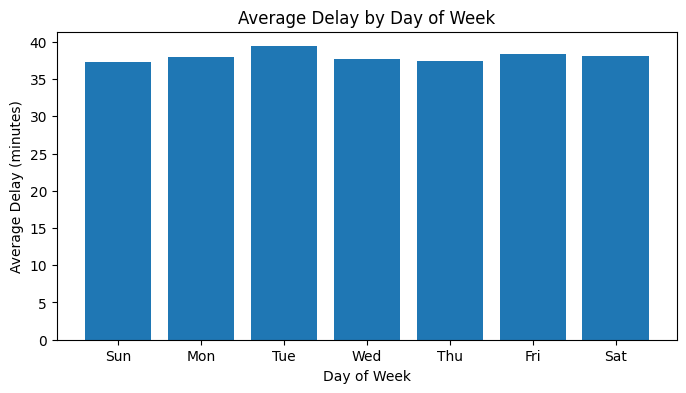

In [ ]:
dow_delay = df2.groupBy("dep_dayofweek").agg(
    sp_round(avg("delay_minutes"), 2).alias("avg_delay_min")
).orderBy("dep_dayofweek")

dow_pd = dow_delay.toPandas()

dow_names = {1:"Sun",2:"Mon",3:"Tue",4:"Wed",5:"Thu",6:"Fri",7:"Sat"}
labels = [dow_names.get(int(x), str(x)) for x in dow_pd["dep_dayofweek"]]

plt.figure(figsize=(8,4))
plt.bar(labels, dow_pd["avg_delay_min"])
plt.xlabel("Day of Week")
plt.ylabel("Average Delay (minutes)")
plt.title("Average Delay by Day of Week")
plt.show()


# **Bar chart: On-time vs Late shipments**

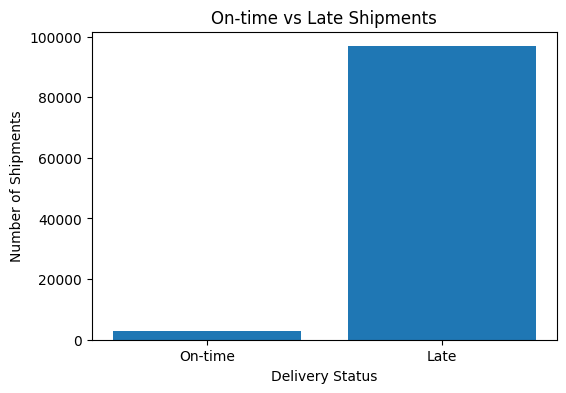

In [ ]:
from pyspark.sql.functions import count

status_counts = df2.groupBy("delivery_status").agg(count("*").alias("shipments"))
s_pd = status_counts.toPandas()

plt.figure(figsize=(6,4))
plt.bar(s_pd["delivery_status"], s_pd["shipments"])
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")
plt.title("On-time vs Late Shipments")
plt.show()


# **Line chart: Average delay by month**

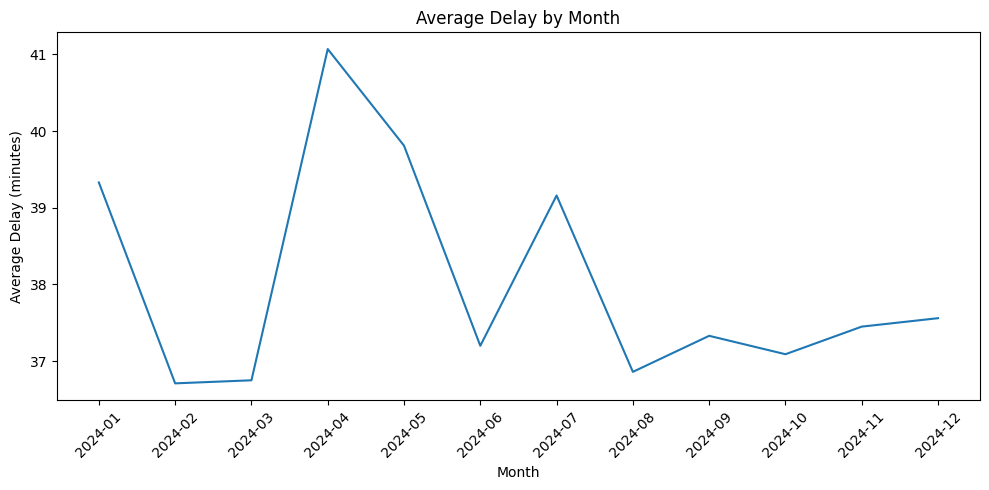

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg, round as sp_round

delay_by_month = df2.groupBy("dep_year", "dep_month").agg(
    sp_round(avg("delay_minutes"), 2).alias("avg_delay_min")
).orderBy("dep_year", "dep_month")

m_pd = delay_by_month.toPandas()

plt.figure(figsize=(10,5))
plt.plot(range(len(m_pd)), m_pd["avg_delay_min"])
plt.xticks(range(len(m_pd)), [f"{y}-{m:02d}" for y, m in zip(m_pd["dep_year"], m_pd["dep_month"])], rotation=45)
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")
plt.title("Average Delay by Month")
plt.tight_layout()
plt.show()


In [ ]:
clean_csv = "translogix_clean_shipments.csv"
origin_csv = "origin_hub_summary.csv"
dest_csv = "destination_hub_summary.csv"
route_csv = "route_summary.csv"

df2.toPandas().to_csv(clean_csv, index=False)
origin_hub_summary.toPandas().to_csv(origin_csv, index=False)
dest_hub_summary.toPandas().to_csv(dest_csv, index=False)
route_summary.toPandas().to_csv(route_csv, index=False)

print("Saved files:", clean_csv, origin_csv, dest_csv, route_csv)


Saved files: translogix_clean_shipments.csv origin_hub_summary.csv destination_hub_summary.csv route_summary.csv


# **Prepare ML dataset**

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

# filtering  (high delays)
high_delay = df2.filter(col("delay_minutes") > 60).select(
    "shipment_id","origin_hub_name","route_name","delay_minutes","origin_congestion_idx","dest_congestion_idx"
)
print("Shipments delayed > 60 min:", high_delay.count())
high_delay.show(5, truncate=False)
# Select features for prediction
feature_cols = [
    "origin_congestion_idx",
    "dest_congestion_idx",
    "distance_km",
    "dep_hour",
    "dep_dayofweek",
    "dep_month",
    "is_peak_hour"
]
ml_df = df2.select(["delay_minutes"] + feature_cols).dropna()
# Train/test split
train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")


Shipments delayed > 60 min: 12460
+-----------+-----------------------+--------------------------------------------+-------------+---------------------+-------------------+
|shipment_id|origin_hub_name        |route_name                                  |delay_minutes|origin_congestion_idx|dest_congestion_idx|
+-----------+-----------------------+--------------------------------------------+-------------+---------------------+-------------------+
|SHP400026  |Dubai Central Hub      |Dubai Central Hub -> Bahrain Regional Hub   |66.0         |0.481481481          |0.6                |
|SHP400029  |Dubai Central Hub      |Dubai Central Hub -> Bahrain Regional Hub   |81.0         |0.333333333          |0.266666667        |
|SHP400044  |Dubai Central Hub      |Dubai Central Hub -> Riyadh Logistics Hub   |69.0         |0.259259259          |0.428571429        |
|SHP400049  |Dubai Central Hub      |Dubai Central Hub -> Bahrain Regional Hub   |66.0         |0.666666667          |0.266666667   

# **Linear Regression**

In [ ]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="delay_minutes")
lr_pipeline = Pipeline(stages=[assembler, lr])
lr_model = lr_pipeline.fit(train_df)
lr_pred = lr_model.transform(test_df)


# **Random Forest Regressor**

In [ ]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(featuresCol="features", labelCol="delay_minutes", numTrees=80, maxDepth=10, seed=42)
rf_pipeline = Pipeline(stages=[assembler, rf])
rf_model = rf_pipeline.fit(train_df)
rf_pred = rf_model.transform(test_df)


# **Gradient-Boosted Trees Regressor**

In [ ]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(featuresCol="features", labelCol="delay_minutes", maxIter=80, maxDepth=6, seed=42)
gbt_pipeline = Pipeline(stages=[assembler, gbt])
gbt_model = gbt_pipeline.fit(train_df)
gbt_pred = gbt_model.transform(test_df)


# **Evaluate models using RMSE and R²**

In [ ]:
evaluator_rmse = RegressionEvaluator(labelCol="delay_minutes", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="delay_minutes", predictionCol="prediction", metricName="r2")

def eval_model(name, pred_df):
    rmse = evaluator_rmse.evaluate(pred_df)
    r2 = evaluator_r2.evaluate(pred_df)
    print(f"{name} -> RMSE: {rmse:.3f}, R2: {r2:.3f}")
    return (name, rmse, r2)

results = []
results.append(eval_model("Linear Regression", lr_pred))
results.append(eval_model("Random Forest", rf_pred))
results.append(eval_model("Gradient-Boosted Trees", gbt_pred))

# Show results sorted by RMSE (lower is better)
results_sorted = sorted(results, key=lambda x: x[1])
print("\nModel comparison (best RMSE first):")
for r in results_sorted:
    print(r)


Linear Regression -> RMSE: 19.948, R2: 0.092
Random Forest -> RMSE: 18.465, R2: 0.222
Gradient-Boosted Trees -> RMSE: 18.399, R2: 0.228

Model comparison (best RMSE first):
('Gradient-Boosted Trees', 18.399436312313163, 0.227683556649115)
('Random Forest', 18.46463833663988, 0.22220014738317329)
('Linear Regression', 19.948391360424484, 0.09217527855973406)


In [ ]:
best = results_sorted[0]
print(f"\nBest model by RMSE is: {best[0]} (RMSE={best[1]:.3f}, R2={best[2]:.3f})")


Best model by RMSE is: Gradient-Boosted Trees (RMSE=18.399, R2=0.228)
